# Análisis Psicométrico y Regresión sobre Intención Emprendedora
**Cabañas M. et al., 2026**

Este notebook realiza:
1. Carga y preparación de datos (escalas Likert 1–5)
2. Estadísticos descriptivos por constructo
3. Fiabilidad interna: Alfa de Cronbach
4. Análisis Factorial Exploratorio (AFE)
5. Regresión múltiple sobre Intención Emprendedora (EI)

---
**Constructos del modelo:**
| Sigla | Constructo | Ítems |
|-------|-----------|-------|
| EI | Intención Emprendedora *(VD)* | EI1–EI5 |
| EA | Actitud Emprendedora | EA1–EA8 |
| DA | Deseo de Autonomía | DA1–DA5 |
| EAc | Competencias Emprendedoras | EAc1–EAc11 |
| FL | Alfabetización Financiera | FL1–FL7 |
| SA | Autoconfianza | SA1–SA3 |
| SR | Autorregulación | SR1–SR4 |
| M | Motivación | M1–M4 |
| E | Resiliencia/Eficacia | E1–E5 |
| SS | Habilidades Sociales | SS1–SS5 |
| ES | Autoeficacia Emprendedora | ES1–ES5 |

## 0. Configuración e importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas cargadas correctamente.')

Matplotlib is building the font cache; this may take a moment.


Bibliotecas cargadas correctamente.


## 1. Carga y preparación de datos

In [2]:
# ── Carga ──────────────────────────────────────────────────────────────────
# El notebook busca primero datos_encuesta_2026.csv (si existe) y luego data.xlsx
import os

if os.path.exists('datos_encuesta_2026.csv'):
    df_raw = pd.read_csv('datos_encuesta_2026.csv')
    print('Datos cargados desde: datos_encuesta_2026.csv')
else:
    df_raw = pd.read_excel('data.xlsx')
    # Guardar copia en CSV para uso futuro
    df_raw.to_csv('datos_encuesta_2026.csv', index=False)
    print('Datos cargados desde: data.xlsx  →  guardado como datos_encuesta_2026.csv')

print(f'Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

Datos cargados desde: data.xlsx  →  guardado como datos_encuesta_2026.csv
Dimensiones: 337 filas × 67 columnas


,Study_Program,Age,Semester,Ent_Exp,Gender,EI1,EI2,EI3,EI4,EI5,...,SS1,SS2,SS3,SS4,SS5,ES1,ES2,ES3,ES4,ES5
0,1,3,5,2,2,3,3,3,4,4,...,3,4,4,3,3,4,4,4,4,3
1,1,1,4,2,2,3,4,4,4,4,...,3,4,4,5,5,3,4,3,3,5
2,1,1,4,1,1,4,4,4,4,4,...,5,5,5,5,5,5,5,5,5,5


In [3]:
# ── Definición de constructos y sus ítems ──────────────────────────────────
CONSTRUCTS = {
    'EI':  [f'EI{i}'  for i in range(1, 6)],          # Intención Emprendedora (VD)
    'EA':  [f'EA{i}'  for i in range(1, 9)],           # Actitud Emprendedora
    'DA':  [f'DA{i}'  for i in range(1, 6)],           # Deseo de Autonomía
    'EAc': [f'EAc{i}' for i in range(1, 12)],          # Competencias Emprendedoras
    'FL':  [f'FL{i}'  for i in range(1, 8)],           # Alfabetización Financiera
    'SA':  [f'SA{i}'  for i in range(1, 4)],           # Autoconfianza
    'SR':  [f'SR{i}'  for i in range(1, 5)],           # Autorregulación
    'M':   [f'M{i}'   for i in range(1, 5)],           # Motivación
    'E':   [f'E{i}'   for i in range(1, 6)],           # Resiliencia/Eficacia
    'SS':  [f'SS{i}'  for i in range(1, 6)],           # Habilidades Sociales
    'ES':  [f'ES{i}'  for i in range(1, 6)],           # Autoeficacia Emprendedora
}

# Variables Likert (todos los ítems de todos los constructos)
ALL_LIKERT = [item for items in CONSTRUCTS.values() for item in items]

# Verificar que todos los ítems existen en el DataFrame
missing_cols = [c for c in ALL_LIKERT if c not in df_raw.columns]
if missing_cols:
    print(f'ADVERTENCIA – Columnas no encontradas: {missing_cols}')
else:
    print(f'Todos los {len(ALL_LIKERT)} ítems Likert verificados correctamente.')

Todos los 62 ítems Likert verificados correctamente.


In [4]:
# ── Codificación / limpieza de la escala Likert ────────────────────────────
df = df_raw.copy()

# Forzar tipo numérico en todos los ítems Likert
df[ALL_LIKERT] = df[ALL_LIKERT].apply(pd.to_numeric, errors='coerce')

# Rango válido: 1–5  (valores fuera se convierten en NaN)
for col in ALL_LIKERT:
    df[col] = df[col].where(df[col].between(1, 5))

# Reporte de valores faltantes
na_report = df[ALL_LIKERT].isna().sum()
print('Ítems con valores faltantes (NaN):')
print(na_report[na_report > 0].to_string() if na_report.any() else '  Ninguno')

# Imputación por media del ítem (método conservador para escalas Likert)
df[ALL_LIKERT] = df[ALL_LIKERT].fillna(df[ALL_LIKERT].mean())

print(f'\nFilas finales para análisis: {len(df)}')

Ítems con valores faltantes (NaN):
  Ninguno



Filas finales para análisis: 337


## 2. Estadísticos descriptivos

In [5]:
# ── Estadísticos descriptivos por constructo ──────────────────────────────
desc_rows = []
for name, items in CONSTRUCTS.items():
    scores = df[items].mean(axis=1)
    desc_rows.append({
        'Constructo': name,
        'N ítems': len(items),
        'Media': round(scores.mean(), 3),
        'DE': round(scores.std(), 3),
        'Mín': round(scores.min(), 3),
        'Máx': round(scores.max(), 3),
        'Asimetría': round(scores.skew(), 3),
        'Curtosis': round(scores.kurt(), 3),
    })

desc_df = pd.DataFrame(desc_rows).set_index('Constructo')
display(desc_df)

,N ítems,Media,DE,Mín,Máx,Asimetría,Curtosis
Constructo,,,,,,,
EI,5,4.221,0.840,1.0,5.0,-1.508,2.813
EA,8,4.204,0.752,1.0,5.0,-1.816,4.707
DA,5,3.477,0.793,1.0,5.0,-0.490,0.464
EAc,11,2.783,0.892,1.0,5.0,0.220,-0.392
FL,7,3.449,0.855,1.0,5.0,-0.700,0.421
SA,3,4.061,0.830,1.0,5.0,-1.356,2.559
SR,4,4.163,0.782,1.0,5.0,-1.617,3.891
M,4,4.048,0.796,1.0,5.0,-1.212,2.409
E,5,3.960,0.755,1.0,5.0,-1.383,3.285


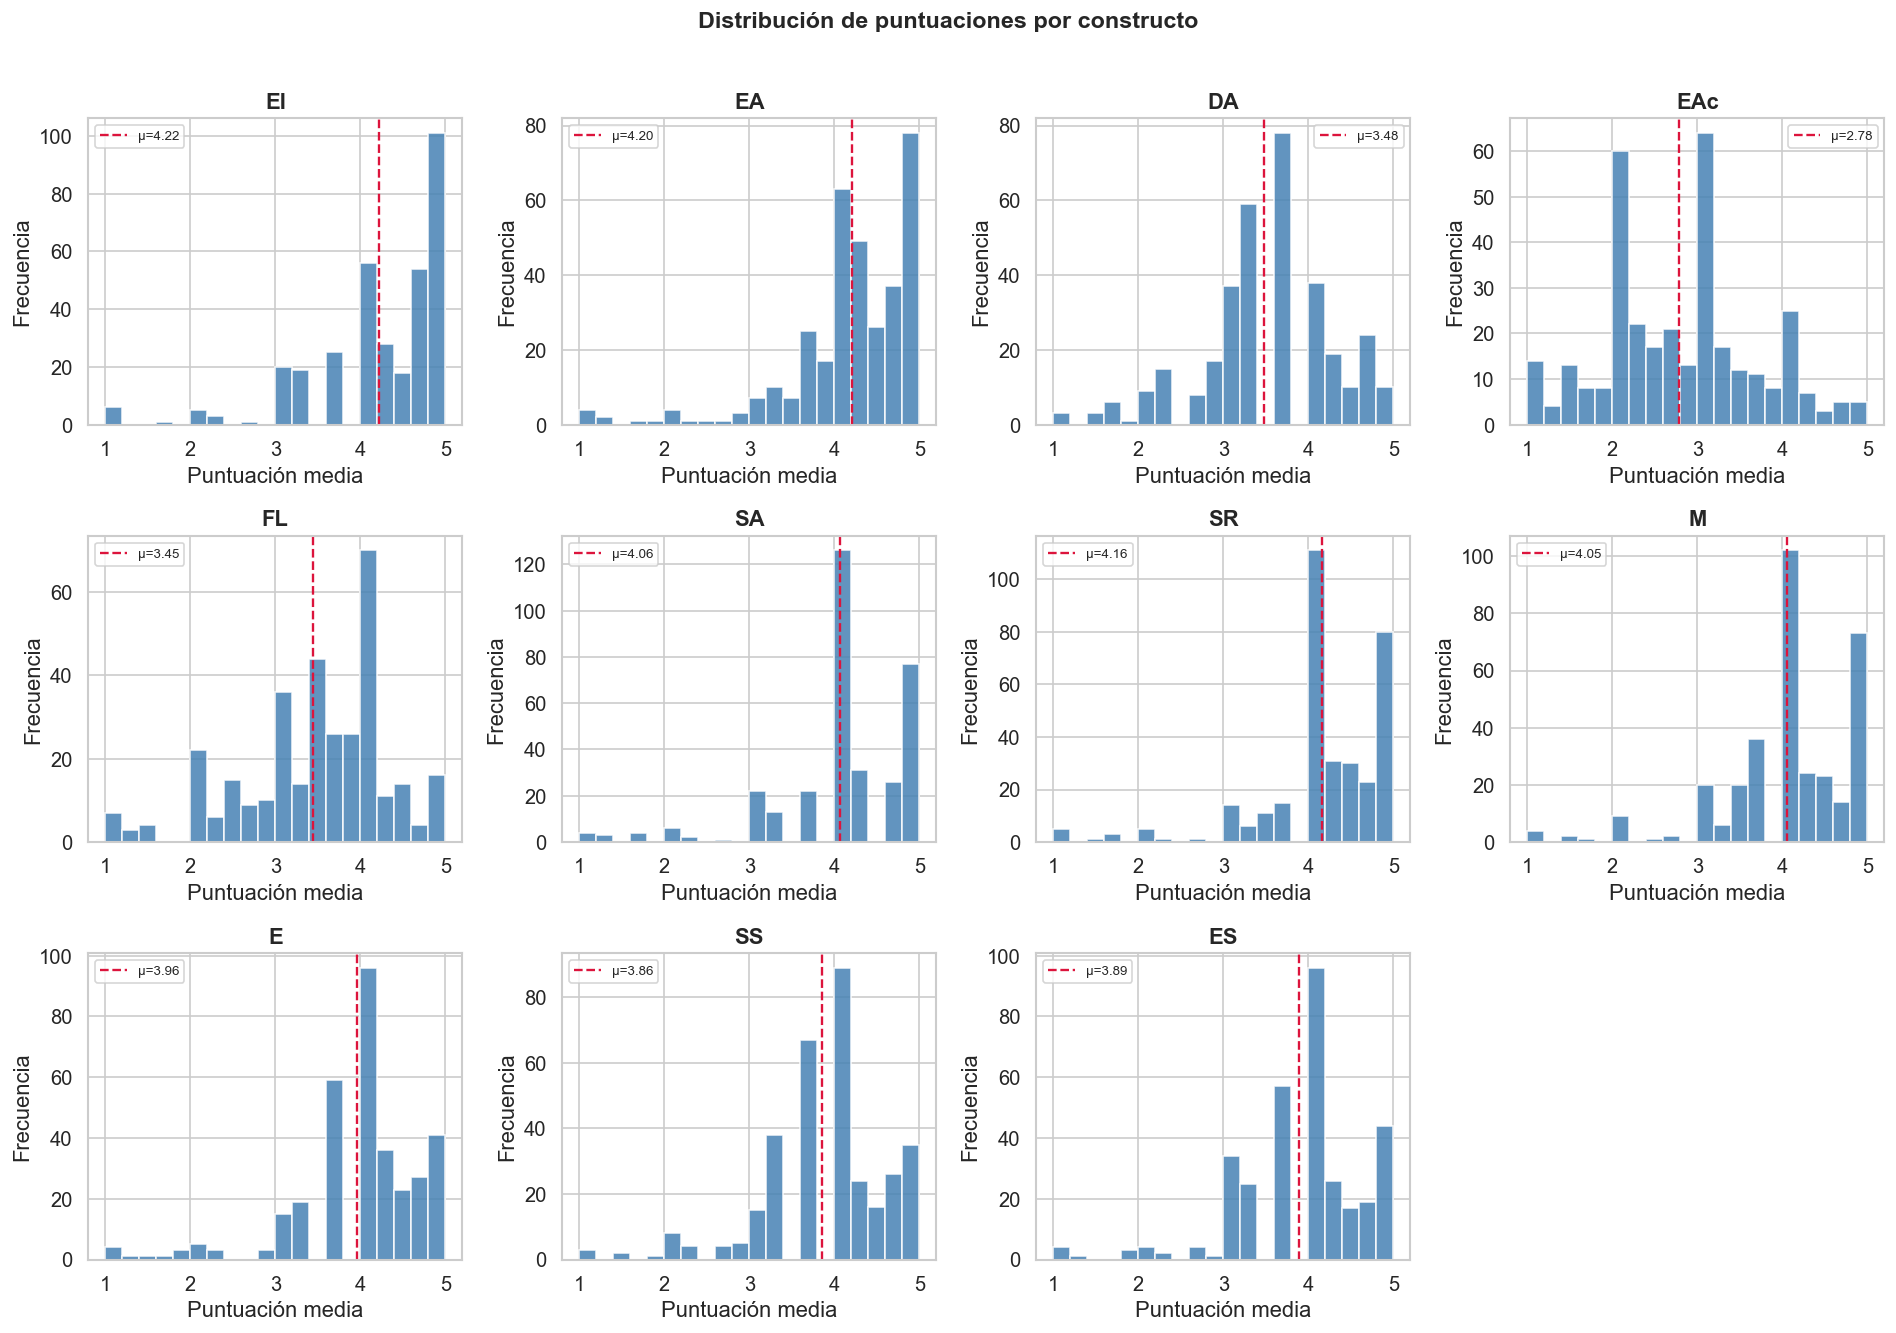

In [6]:
# ── Distribución de puntuaciones por constructo ───────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for ax, (name, items) in zip(axes, CONSTRUCTS.items()):
    scores = df[items].mean(axis=1)
    ax.hist(scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(scores.mean(), color='crimson', linestyle='--', linewidth=1.4,
               label=f'μ={scores.mean():.2f}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Puntuación media')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Ocultar ejes sobrantes
for ax in axes[len(CONSTRUCTS):]:
    ax.set_visible(False)

plt.suptitle('Distribución de puntuaciones por constructo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Fiabilidad: Alfa de Cronbach

In [7]:
def cronbach_alpha(data: pd.DataFrame) -> dict:
    """Calcula el alfa de Cronbach y sus componentes para una matriz de ítems."""
    k = data.shape[1]
    item_vars = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_vars.sum() / total_var)

    # Alfa si se elimina cada ítem
    alpha_if_deleted = {}
    for col in data.columns:
        reduced = data.drop(columns=col)
        kd = reduced.shape[1]
        iv = reduced.var(axis=0, ddof=1)
        tv = reduced.sum(axis=1).var(ddof=1)
        alpha_if_deleted[col] = round((kd / (kd - 1)) * (1 - iv.sum() / tv), 4)

    return {
        'alpha': round(alpha, 4),
        'k': k,
        'alpha_if_deleted': alpha_if_deleted
    }


def interpret_alpha(a: float) -> str:
    if a >= 0.90: return 'Excelente'
    if a >= 0.80: return 'Bueno'
    if a >= 0.70: return 'Aceptable'
    if a >= 0.60: return 'Cuestionable'
    if a >= 0.50: return 'Pobre'
    return 'Inaceptable'


# ── Calcular alfa para cada constructo ───────────────────────────────────
alpha_results = []
alpha_detail = {}

for name, items in CONSTRUCTS.items():
    res = cronbach_alpha(df[items])
    alpha_detail[name] = res
    alpha_results.append({
        'Constructo': name,
        'N ítems': res['k'],
        'α Cronbach': res['alpha'],
        'Interpretación': interpret_alpha(res['alpha'])
    })

alpha_df = pd.DataFrame(alpha_results).set_index('Constructo')
display(alpha_df)

,N ítems,α Cronbach,Interpretación
Constructo,,,
EI,5,0.9428,Excelente
EA,8,0.9137,Excelente
DA,5,0.8584,Bueno
EAc,11,0.9347,Excelente
FL,7,0.9203,Excelente
SA,3,0.9127,Excelente
SR,4,0.9375,Excelente
M,4,0.9281,Excelente
E,5,0.9158,Excelente


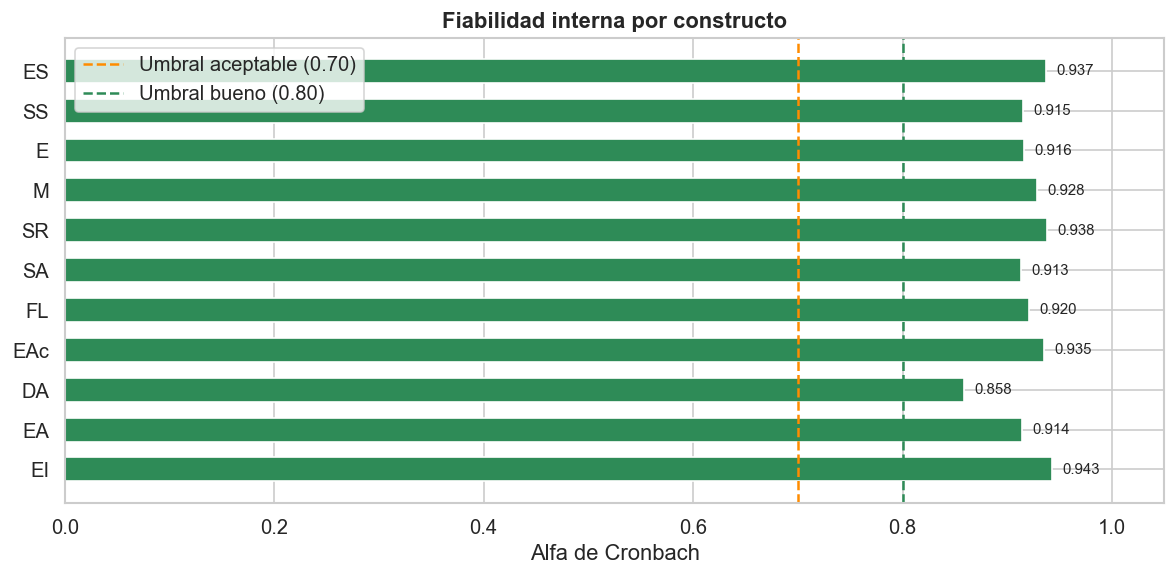

In [8]:
# ── Gráfico de alfa de Cronbach ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
constructs_list = alpha_df.index.tolist()
alphas = alpha_df['α Cronbach'].values

colors = ['seagreen' if a >= 0.70 else 'darkorange' if a >= 0.60 else 'crimson'
          for a in alphas]
bars = ax.barh(constructs_list, alphas, color=colors, edgecolor='white', height=0.6)

ax.axvline(0.70, color='darkorange', linestyle='--', linewidth=1.5, label='Umbral aceptable (0.70)')
ax.axvline(0.80, color='seagreen',   linestyle='--', linewidth=1.5, label='Umbral bueno (0.80)')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Alfa de Cronbach')
ax.set_title('Fiabilidad interna por constructo', fontweight='bold')
ax.legend()

for bar, val in zip(bars, alphas):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# ── Detalle: alfa si se elimina cada ítem (por constructo) ────────────────
print('=== Alfa si se elimina el ítem ===\n')
for name, res in alpha_detail.items():
    print(f'── {name}  (α total = {res["alpha"]}) ─────────────')
    aid = pd.Series(res['alpha_if_deleted'], name='α si se elimina')
    df_aid = aid.to_frame()
    df_aid['Δα'] = df_aid['α si se elimina'] - res['alpha']
    df_aid['Δα'] = df_aid['Δα'].apply(lambda x: f'+{x:.4f}' if x > 0 else f'{x:.4f}')
    print(df_aid.to_string())
    print()

=== Alfa si se elimina el ítem ===

── EI  (α total = 0.9428) ─────────────
     α si se elimina       Δα
EI1           0.9422  -0.0006
EI2           0.9275  -0.0153
EI3           0.9201  -0.0227
EI4           0.9244  -0.0184
EI5           0.9332  -0.0096

── EA  (α total = 0.9137) ─────────────
     α si se elimina       Δα
EA1           0.8993  -0.0144
EA2           0.8965  -0.0172
EA3           0.8994  -0.0143
EA4           0.8993  -0.0144
EA5           0.9057  -0.0080
EA6           0.9012  -0.0125
EA7           0.9137   0.0000
EA8           0.9053  -0.0084

── DA  (α total = 0.8584) ─────────────
     α si se elimina       Δα
DA1           0.8449  -0.0135
DA2           0.8043  -0.0541
DA3           0.8066  -0.0518
DA4           0.8200  -0.0384
DA5           0.8639  +0.0055

── EAc  (α total = 0.9347) ─────────────
       α si se elimina       Δα
EAc1            0.9332  -0.0015
EAc2            0.9287  -0.0060
EAc3            0.9295  -0.0052
EAc4            0.9330  -0.0017
EAc5      

## 4. Análisis Factorial Exploratorio (AFE)

In [10]:
# ── Preparar matriz de ítems Likert ──────────────────────────────────────
X_afe = df[ALL_LIKERT].copy()

# ── Supuestos: KMO y prueba de esfericidad de Bartlett ───────────────────
kmo_all, kmo_model = calculate_kmo(X_afe)
chi2, p_bart = calculate_bartlett_sphericity(X_afe)

print('=== Supuestos del AFE ===')
print(f'KMO global:              {kmo_model:.4f}  ', end='')
if kmo_model >= 0.90:   print('(Maravilloso)')
elif kmo_model >= 0.80: print('(Meritorio)')
elif kmo_model >= 0.70: print('(Mediano)')
elif kmo_model >= 0.60: print('(Mediocre)')
else:                   print('(Inaceptable – no continuar)')

print(f'Bartlett  χ²={chi2:.2f},  p={p_bart:.4e}  ',
      '→ Se rechaza H0 (matriz ≠ identidad)' if p_bart < 0.05 else '→ No se rechaza H0')

=== Supuestos del AFE ===
KMO global:              0.9424  (Maravilloso)
Bartlett  χ²=19604.58,  p=0.0000e+00   → Se rechaza H0 (matriz ≠ identidad)


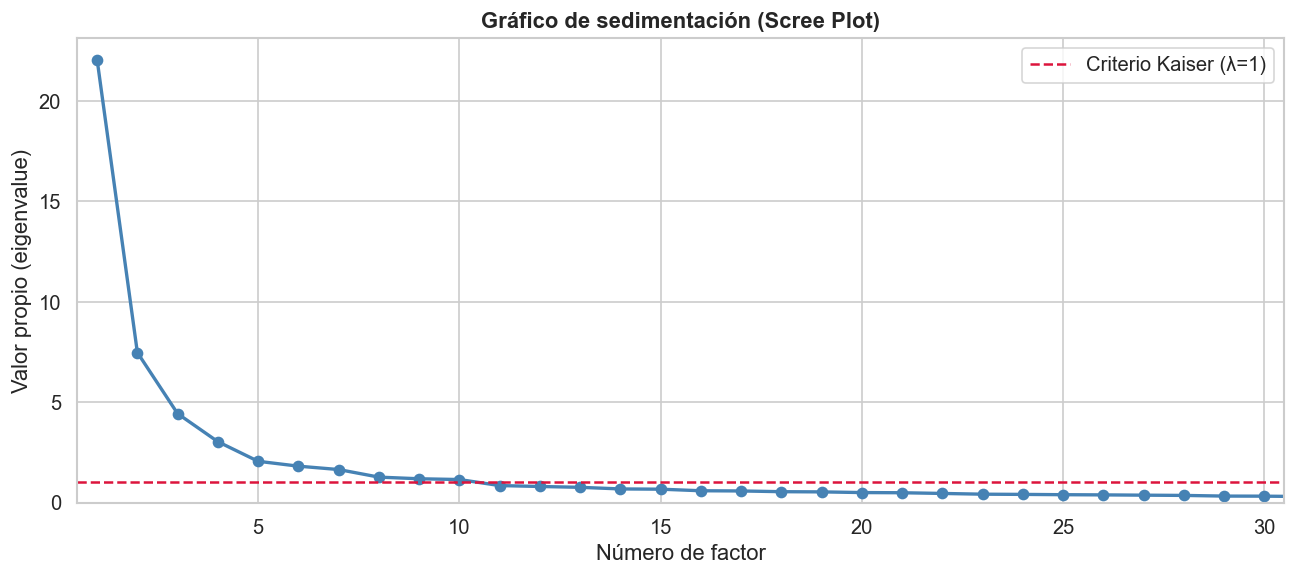

Factores con λ > 1 (criterio Kaiser): 10


In [11]:
# ── Gráfico de sedimentación para determinar nro. de factores ─────────────
fa_scree = FactorAnalyzer(n_factors=len(ALL_LIKERT), rotation=None)
fa_scree.fit(X_afe)
ev, _ = fa_scree.get_eigenvalues()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(1, len(ev) + 1), ev, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axhline(1, color='crimson', linestyle='--', linewidth=1.5, label='Criterio Kaiser (λ=1)')
ax.set_xlim(0.5, min(30, len(ev)) + 0.5)
ax.set_ylim(bottom=0)
ax.set_xlabel('Número de factor')
ax.set_ylabel('Valor propio (eigenvalue)')
ax.set_title('Gráfico de sedimentación (Scree Plot)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

n_factors_kaiser = int((ev > 1).sum())
print(f'Factores con λ > 1 (criterio Kaiser): {n_factors_kaiser}')

In [12]:
# ── AFE con rotación Oblimin (factores correlacionados) ───────────────────
# Se usa el número de factores sugerido por Kaiser; ajustar si la teoría lo indica
N_FACTORS = n_factors_kaiser  # ← modificar si se requiere un nro. teórico diferente

fa = FactorAnalyzer(n_factors=N_FACTORS, rotation='oblimin', method='minres')
fa.fit(X_afe)

# Varianza explicada
var_table = fa.get_factor_variance()
var_df = pd.DataFrame(
    var_table,
    index=['Varianza', 'Prop. varianza', 'Prop. acumulada'],
    columns=[f'F{i+1}' for i in range(N_FACTORS)]
).T

print(f'=== Varianza explicada ({N_FACTORS} factores, rotación Oblimin) ===')
display(var_df.round(4))
print(f'\nVarianza total explicada: {var_df["Prop. varianza"].sum()*100:.1f}%')

=== Varianza explicada (10 factores, rotación Oblimin) ===


,Varianza,Prop. varianza,Prop. acumulada
F1,4.3455,0.0701,0.0701
F2,4.2577,0.0687,0.1388
F3,3.9036,0.0630,0.2017
F4,3.8932,0.0628,0.2645
F5,3.8799,0.0626,0.3271
F6,3.4226,0.0552,0.3823
F7,3.0435,0.0491,0.4314
F8,2.6017,0.0420,0.4733
F9,2.1982,0.0355,0.5088
F10,2.0947,0.0338,0.5426



Varianza total explicada: 54.3%


In [13]:
# ── Matriz de cargas factoriales ──────────────────────────────────────────
loadings = pd.DataFrame(
    fa.loadings_,
    index=ALL_LIKERT,
    columns=[f'F{i+1}' for i in range(N_FACTORS)]
)

# Resaltar cargas ≥ 0.40 (criterio común en investigación)
def highlight_loadings(val):
    return 'font-weight: bold; color: crimson' if abs(val) >= 0.40 else ''

print('=== Matriz de cargas factoriales (negrita = |carga| ≥ 0.40) ===')
display(loadings.style.applymap(highlight_loadings).format('{:.3f}'))

=== Matriz de cargas factoriales (negrita = |carga| ≥ 0.40) ===


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
EI1,-0.012,0.071,0.085,0.764,0.032,0.021,0.018,0.012,-0.057,-0.042
EI2,0.025,0.022,-0.014,0.814,0.067,0.077,-0.033,0.040,-0.044,-0.027
EI3,-0.012,-0.019,-0.005,0.920,0.020,0.007,0.013,0.009,0.010,-0.010
EI4,-0.021,-0.021,0.037,0.888,-0.023,0.023,0.026,-0.009,0.073,-0.008
EI5,0.055,0.001,-0.060,0.844,-0.048,0.043,0.059,-0.066,-0.026,0.088
EA1,-0.039,0.033,0.026,0.188,0.113,0.615,-0.066,0.182,0.014,-0.100
EA2,0.009,-0.042,0.090,0.061,0.107,0.690,0.014,0.103,0.080,-0.069
EA3,-0.054,-0.017,-0.095,0.190,-0.043,0.663,0.058,0.031,0.119,0.107
EA4,0.027,0.094,-0.021,0.153,0.038,0.572,-0.015,0.036,0.175,-0.003
EA5,0.049,-0.049,0.068,0.025,0.086,0.703,0.083,-0.040,-0.142,-0.089


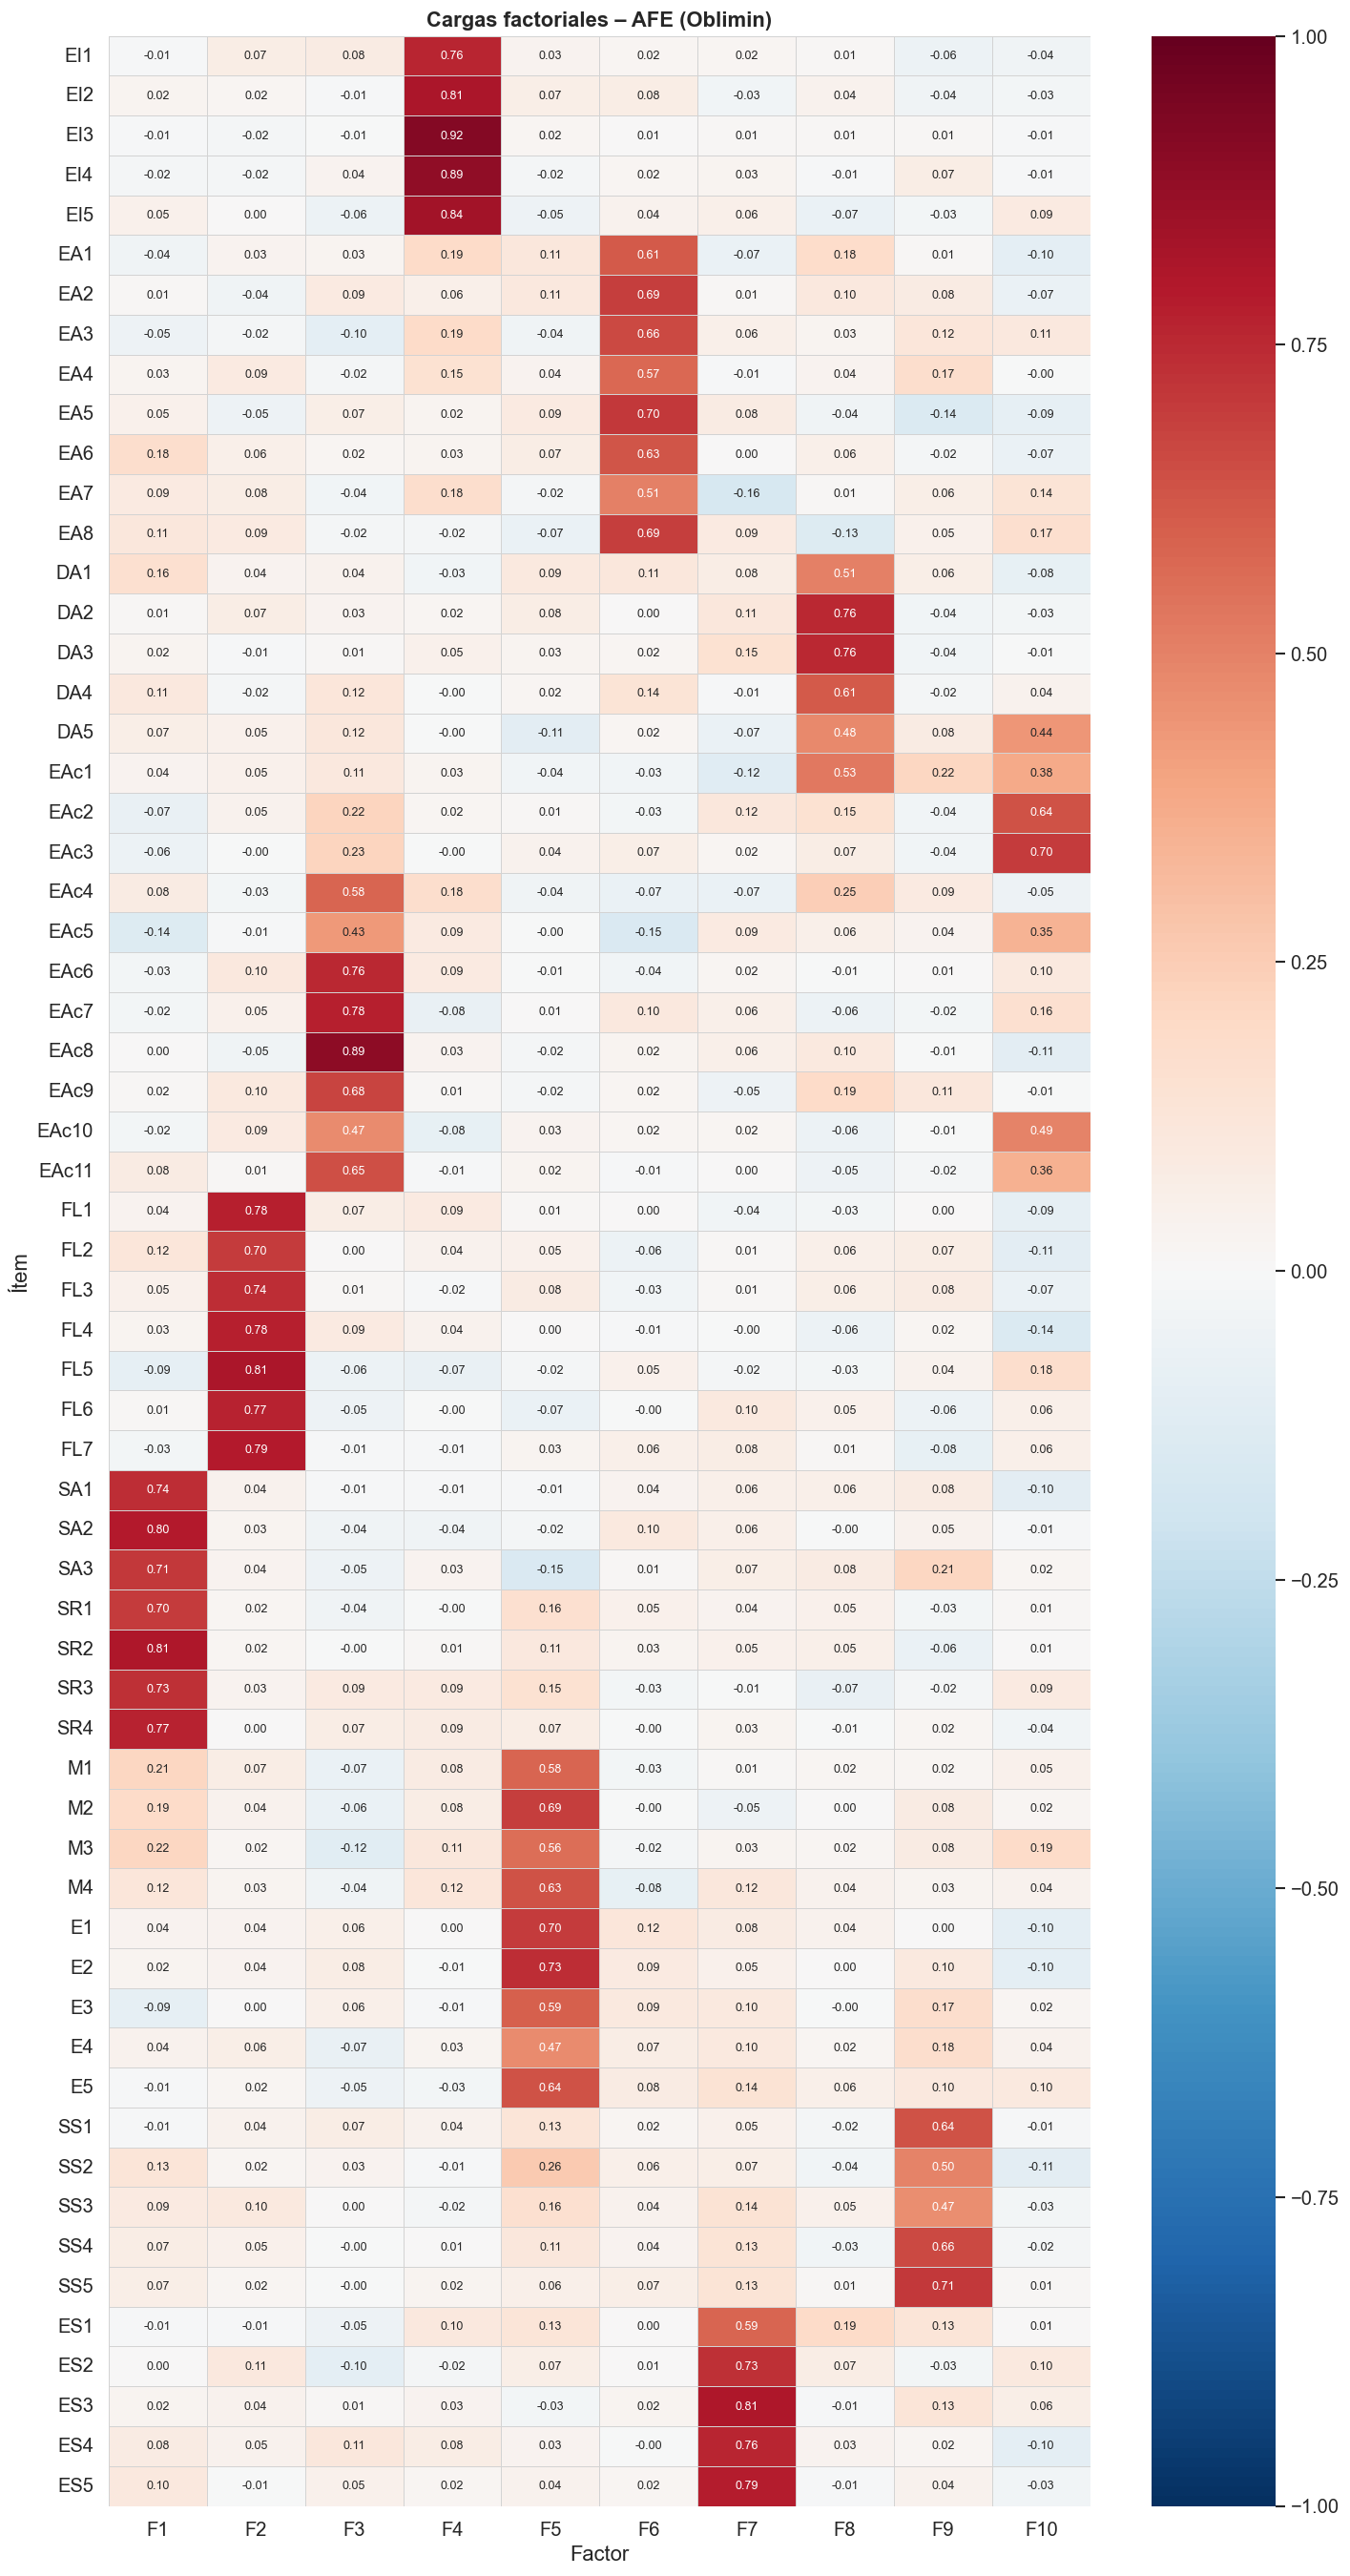

In [14]:
# ── Heatmap de cargas factoriales ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, N_FACTORS * 1.2), len(ALL_LIKERT) * 0.35 + 1))
mask = np.abs(loadings.values) < 0.30   # ocultar cargas débiles
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='lightgrey',
    annot_kws={'size': 7.5}, ax=ax
)
ax.set_title('Cargas factoriales – AFE (Oblimin)', fontweight='bold')
ax.set_xlabel('Factor')
ax.set_ylabel('Ítem')
plt.tight_layout()
plt.show()

In [15]:
# ── Asignación de ítems al factor con mayor carga ─────────────────────────
loadings['Factor_asignado'] = loadings.iloc[:, :N_FACTORS].abs().idxmax(axis=1)
loadings['Carga_máx'] = loadings.iloc[:, :N_FACTORS].abs().max(axis=1).round(3)

print('=== Asignación de ítems a factores ===')
display(
    loadings[['Factor_asignado', 'Carga_máx']]
    .sort_values(['Factor_asignado', 'Carga_máx'], ascending=[True, False])
)

=== Asignación de ítems a factores ===


,Factor_asignado,Carga_máx
SR2,F1,0.806
SA2,F1,0.796
SR4,F1,0.773
SA1,F1,0.741
SR3,F1,0.730
...,...,...
SS5,F9,0.706
SS4,F9,0.660
SS1,F9,0.637
SS2,F9,0.498


## 5. Regresión Múltiple sobre Intención Emprendedora (EI)

In [16]:
# ── Construir puntuaciones de constructo (media de ítems) ─────────────────
for name, items in CONSTRUCTS.items():
    df[f'score_{name}'] = df[items].mean(axis=1)

# Variable dependiente e independientes
VD = 'score_EI'
PREDICTORS = [f'score_{c}' for c in CONSTRUCTS if c != 'EI']

print('Variable dependiente:', VD)
print('Predictores:', PREDICTORS)

Variable dependiente: score_EI
Predictores: ['score_EA', 'score_DA', 'score_EAc', 'score_FL', 'score_SA', 'score_SR', 'score_M', 'score_E', 'score_SS', 'score_ES']


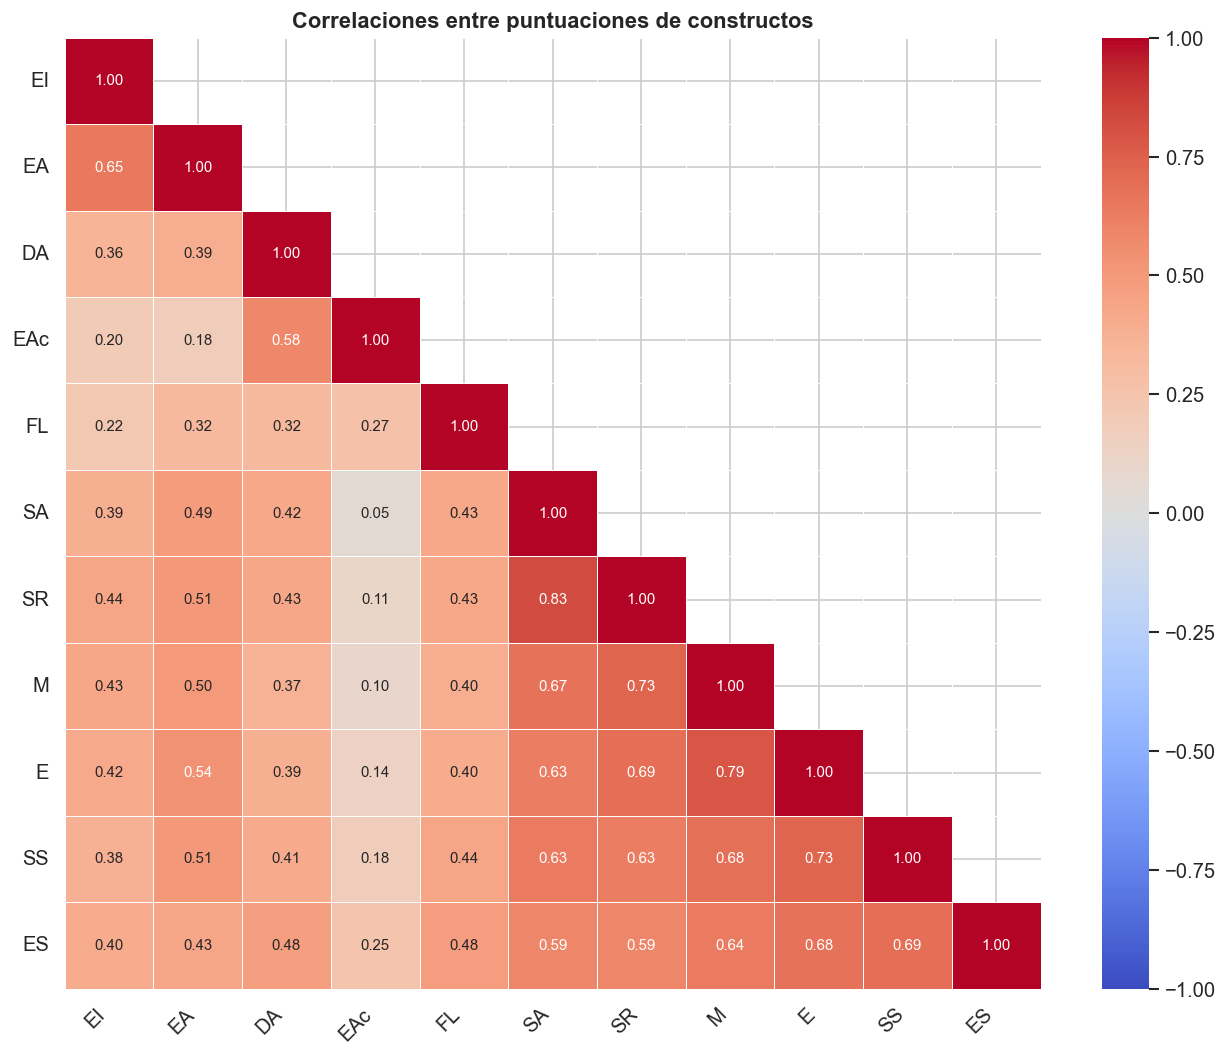

In [17]:
# ── Matriz de correlaciones entre puntuaciones ───────────────────────────
score_cols = [VD] + PREDICTORS
corr_mat = df[score_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    mask=mask_upper,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
labels = [c.replace('score_', '') for c in score_cols]
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)
ax.set_title('Correlaciones entre puntuaciones de constructos', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── Diagnóstico de multicolinealidad (VIF) ────────────────────────────────
X_vif = df[PREDICTORS].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Predictor': PREDICTORS,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1)
            for i in range(len(PREDICTORS))]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['Diagnóstico'] = vif_data['VIF'].apply(
    lambda v: 'Sin problema' if v < 3 else ('Moderado' if v < 5 else 'Alto'))

print('=== Factor de Inflación de Varianza (VIF) ===')
display(vif_data.set_index('Predictor'))

=== Factor de Inflación de Varianza (VIF) ===


,VIF,Diagnóstico
Predictor,,
score_EA,1.577,Sin problema
score_DA,2.096,Sin problema
score_EAc,1.723,Sin problema
score_FL,1.442,Sin problema
score_SA,3.665,Moderado
score_SR,4.002,Moderado
score_M,3.369,Moderado
score_E,3.594,Moderado
score_SS,2.798,Sin problema


In [19]:
# ── Modelo de regresión múltiple (OLS) ───────────────────────────────────
y = df[VD]
X = sm.add_constant(df[PREDICTORS])

modelo_ols = sm.OLS(y, X).fit(cov_type='HC3')  # errores robustos a heterocedasticidad

print(modelo_ols.summary(
    xname=['Constante'] + [c.replace('score_', '') for c in PREDICTORS],
    title='Regresión OLS – Intención Emprendedora (EI)'
))

                 Regresión OLS – Intención Emprendedora (EI)                  
Dep. Variable:               score_EI   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     20.63
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           1.42e-29
Time:                        12:10:36   Log-Likelihood:                -314.14
No. Observations:                 337   AIC:                             650.3
Df Residuals:                     326   BIC:                             692.3
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Constante      0.6721      0.328      2.052      0.0

In [20]:
# ── Tabla de coeficientes con betas estandarizados ────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(df[PREDICTORS]),
    columns=PREDICTORS
)
y_std = (df[VD] - df[VD].mean()) / df[VD].std()

modelo_std = sm.OLS(y_std, sm.add_constant(X_std)).fit(cov_type='HC3')

betas_df = pd.DataFrame({
    'Predictor': [c.replace('score_', '') for c in PREDICTORS],
    'β no estand.': modelo_ols.params[1:].round(4).values,
    'β estand.': modelo_std.params[1:].round(4).values,
    'p-valor': modelo_ols.pvalues[1:].round(4).values,
    'IC95% inf': modelo_ols.conf_int(alpha=0.05)[0][1:].round(4).values,
    'IC95% sup': modelo_ols.conf_int(alpha=0.05)[1][1:].round(4).values,
}).set_index('Predictor')

betas_df['Sig.'] = betas_df['p-valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

print('=== Coeficientes de la regresión múltiple ===')
display(betas_df)

=== Coeficientes de la regresión múltiple ===


,β no estand.,β estand.,p-valor,IC95% inf,IC95% sup,Sig.
Predictor,,,,,,
EA,0.6310,0.5634,0.0000,0.4221,0.8398,***
DA,0.0441,0.0415,0.6325,-0.1366,0.2248,
EAc,0.0569,0.0603,0.2855,-0.0475,0.1613,
FL,-0.0722,-0.0733,0.1942,-0.1811,0.0368,
SA,-0.0672,-0.0662,0.3525,-0.2088,0.0744,
SR,0.1509,0.1403,0.1216,-0.0402,0.3421,
M,0.1250,0.1182,0.2544,-0.0899,0.3398,
E,-0.0710,-0.0637,0.5179,-0.2862,0.1442,
SS,-0.0936,-0.0832,0.3849,-0.3048,0.1176,


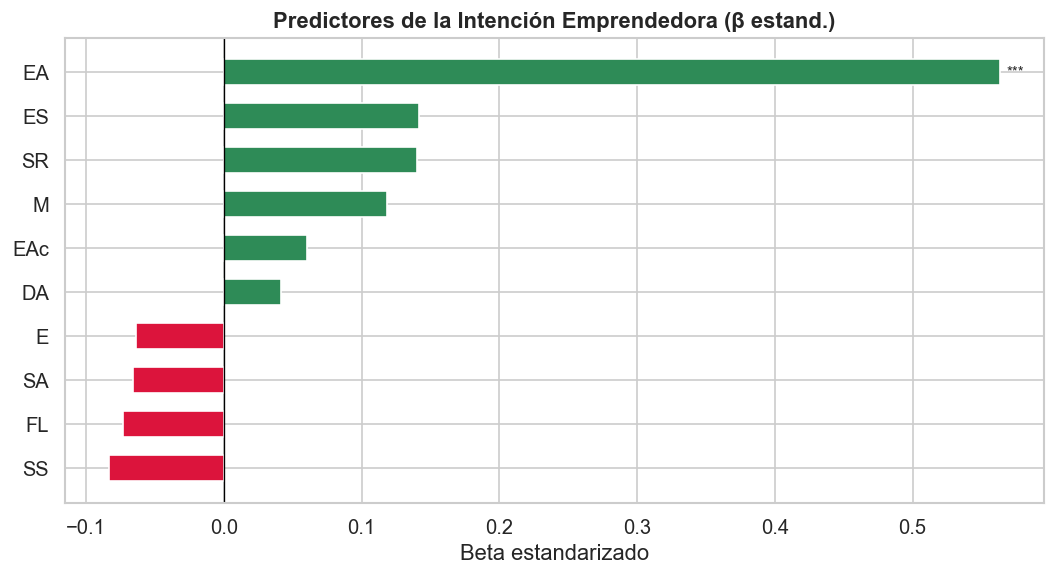


R² = 0.4636  |  R² ajustado = 0.4472
F(10, 326) = 20.632,  p = 1.4236e-29


In [21]:
# ── Gráfico de coeficientes estandarizados ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sorted_betas = betas_df['β estand.'].sort_values()
colors = ['seagreen' if v > 0 else 'crimson' for v in sorted_betas]

ax.barh(sorted_betas.index, sorted_betas.values, color=colors,
        edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Beta estandarizado')
ax.set_title('Predictores de la Intención Emprendedora (β estand.)', fontweight='bold')

for i, (pred, val) in enumerate(sorted_betas.items()):
    sig = betas_df.loc[pred, 'Sig.']
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, i, sig, va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nR² = {modelo_ols.rsquared:.4f}  |  R² ajustado = {modelo_ols.rsquared_adj:.4f}')
print(f'F({modelo_ols.df_model:.0f}, {modelo_ols.df_resid:.0f}) = {modelo_ols.fvalue:.3f},  p = {modelo_ols.f_pvalue:.4e}')

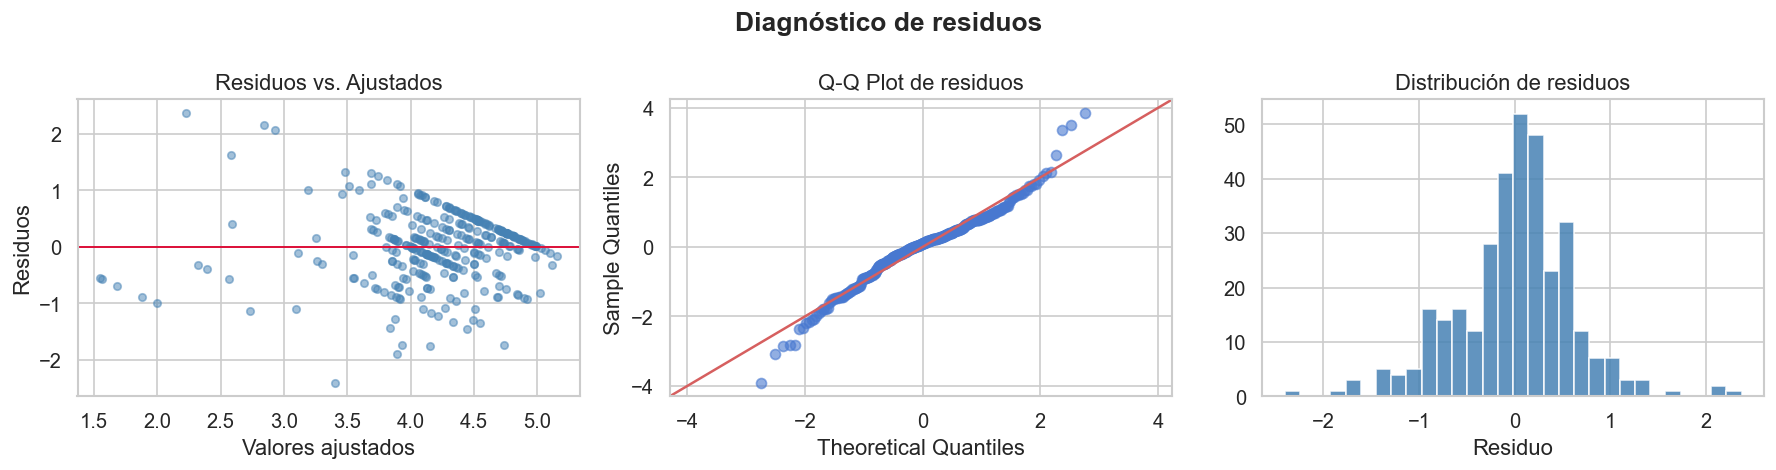

Prueba Shapiro-Wilk sobre residuos: W=0.9702, p=0.0000 → Desviación de normalidad (usar errores robustos HC3)


In [22]:
# ── Diagnósticos de residuos ──────────────────────────────────────────────
residuos = modelo_ols.resid
fitted   = modelo_ols.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuos vs. valores ajustados
axes[0].scatter(fitted, residuos, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='crimson', linewidth=1.2)
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Ajustados')

# 2. Q-Q Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[1], alpha=0.6)
axes[1].set_title('Q-Q Plot de residuos')

# 3. Histograma de residuos
axes[2].hist(residuos, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Residuo')
axes[2].set_title('Distribución de residuos')

plt.suptitle('Diagnóstico de residuos', fontweight='bold')
plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
stat_sw, p_sw = stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=42))
print(f'Prueba Shapiro-Wilk sobre residuos: W={stat_sw:.4f}, p={p_sw:.4f}',
      '→ Normalidad aceptable' if p_sw > 0.05 else '→ Desviación de normalidad (usar errores robustos HC3)')

## 6. Resumen ejecutivo

In [23]:
# ── Resumen integrado ─────────────────────────────────────────────────────
print('=' * 62)
print('RESUMEN EJECUTIVO DEL ANÁLISIS')
print('=' * 62)

print('\n── FIABILIDAD (Alfa de Cronbach) ──────────────────────────')
for _, row in alpha_df.reset_index().iterrows():
    flag = '' if row['α Cronbach'] >= 0.70 else '  ← REVISAR'
    print(f"  {row['Constructo']:5s}  α = {row['α Cronbach']:.3f}  {row['Interpretación']}{flag}")

print(f'\n── AFE ({N_FACTORS} factores, Oblimin) ───────────────────────────')
print(f'  KMO = {kmo_model:.3f}')
print(f'  Bartlett p = {p_bart:.2e}')
print(f'  Varianza total explicada = {var_df["Prop. varianza"].sum()*100:.1f}%')

print('\n── REGRESIÓN MÚLTIPLE (VD = EI) ────────────────────────────')
print(f'  R²  = {modelo_ols.rsquared:.4f}')
print(f'  R²aj= {modelo_ols.rsquared_adj:.4f}')
print(f'  F   = {modelo_ols.fvalue:.3f},  p = {modelo_ols.f_pvalue:.2e}')
print()
sig_preds = betas_df[betas_df['p-valor'] < 0.05].sort_values('β estand.', ascending=False)
print('  Predictores significativos (p < 0.05):')
if len(sig_preds) == 0:
    print('    (ninguno alcanza p < 0.05 individualmente)')
else:
    for pred, row in sig_preds.iterrows():
        print(f"    {pred:5s}  β* = {row['β estand.']:+.3f}  p = {row['p-valor']:.4f} {row['Sig.']}")

print('\n' + '=' * 62)

RESUMEN EJECUTIVO DEL ANÁLISIS

── FIABILIDAD (Alfa de Cronbach) ──────────────────────────
  EI     α = 0.943  Excelente
  EA     α = 0.914  Excelente
  DA     α = 0.858  Bueno
  EAc    α = 0.935  Excelente
  FL     α = 0.920  Excelente
  SA     α = 0.913  Excelente
  SR     α = 0.938  Excelente
  M      α = 0.928  Excelente
  E      α = 0.916  Excelente
  SS     α = 0.915  Excelente
  ES     α = 0.937  Excelente

── AFE (10 factores, Oblimin) ───────────────────────────
  KMO = 0.942
  Bartlett p = 0.00e+00
  Varianza total explicada = 54.3%

── REGRESIÓN MÚLTIPLE (VD = EI) ────────────────────────────
  R²  = 0.4636
  R²aj= 0.4472
  F   = 20.632,  p = 1.42e-29

  Predictores significativos (p < 0.05):
    EA     β* = +0.563  p = 0.0000 ***

